In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [106]:
words = open('names.txt','r').read().splitlines()

In [107]:
len(words)

32033

In [108]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [156]:
block_size = 3
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [158]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [176]:
C = torch.randn((27, 2))
C

tensor([[ 1.4345, -0.8759],
        [-1.9760, -0.2655],
        [-0.7813, -0.7559],
        [ 1.2817,  0.8451],
        [-1.4413,  0.8196],
        [-1.5388,  0.4808],
        [ 0.3136, -0.6993],
        [-0.1877, -0.6144],
        [ 0.3990, -0.2261],
        [ 0.1656,  0.2062],
        [ 0.9941, -0.1806],
        [ 0.0837,  0.3567],
        [-0.9392,  0.3806],
        [ 0.4419, -0.0729],
        [ 0.9149,  0.2612],
        [ 0.5359, -0.4427],
        [-0.6198, -1.9808],
        [ 2.6697, -0.1429],
        [ 0.3580,  0.7103],
        [-1.4581, -0.5646],
        [ 1.2016, -0.9221],
        [ 0.5134, -0.9077],
        [-0.1459,  0.4801],
        [ 1.1958,  0.2665],
        [ 0.4643, -0.6821],
        [ 1.2402,  0.0413],
        [ 0.4604, -0.8811]])

In [22]:
C[5]

tensor([ 1.5336, -1.0327])

In [21]:
F.one_hot(torch.tensor(5), num_classes = 27).float() @ C

tensor([ 1.5336, -1.0327])

In [24]:
C[torch.tensor([3,5,6,7,7,7])]

tensor([[-0.5465, -0.1192],
        [ 1.5336, -1.0327],
        [-0.4697, -0.1854],
        [ 1.0679,  1.0332],
        [ 1.0679,  1.0332],
        [ 1.0679,  1.0332]])

In [26]:
C[X].shape

torch.Size([32, 3, 2])

In [27]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [177]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [33]:
emb[:, 0 , :].shape

torch.Size([32, 2])

In [37]:
#inefficient
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [44]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [47]:
a = torch.arange(18)
a.shape

torch.Size([18])

In [48]:
a.view([3, 3, 2])

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [95]:
emb = emb.view([-1, 6])

In [96]:
h = emb @ W1 + b1
h.shape

torch.Size([32, 100])

In [97]:
h = torch.tanh(h)
h.shape

torch.Size([32, 100])

In [178]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [99]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [100]:
counts = logits.exp()

In [101]:
probs = counts/counts.sum(1, keepdims= True)

In [102]:
probs[0].sum()

tensor(1.)

In [103]:
loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(18.7082)

In [104]:
loss = F.cross_entropy(logits, Y)
loss

tensor(18.7082)

In [262]:
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [332]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 20), generator=g)
W1 = torch.randn((60, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [333]:
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters)

18167

In [252]:
lre = torch.linspace(-3, 0, 1000)
lrs =  10 ** lre

In [334]:
lri = []
lossi = []
stepi=[]

In [335]:
#forward
for i in range(50000):
    ix = torch.randint(0, Xtr.shape[0], (96,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,60) @ W1 + b1)
    logits = logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    #backward
    lr 
    if(i<=20000):
        lr = 1
    elif(i<=40000):
        lr = 0.05
    else:
        lr = 0.01
    for p in parameters:
        p.grad = None
    loss.backward()
    # lr = lrs[i]
    for p in parameters:
        p.data+= -lr * p.grad
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
print(loss.item())

2.25594162940979


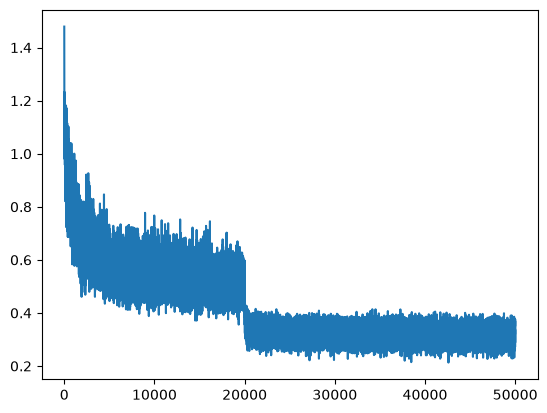

In [336]:
plt.plot(stepi,lossi)

In [337]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,60) @ W1 + b1)
logits = logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0746, grad_fn=<NllLossBackward0>)

In [338]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,60) @ W1 + b1)
logits = logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1283, grad_fn=<NllLossBackward0>)

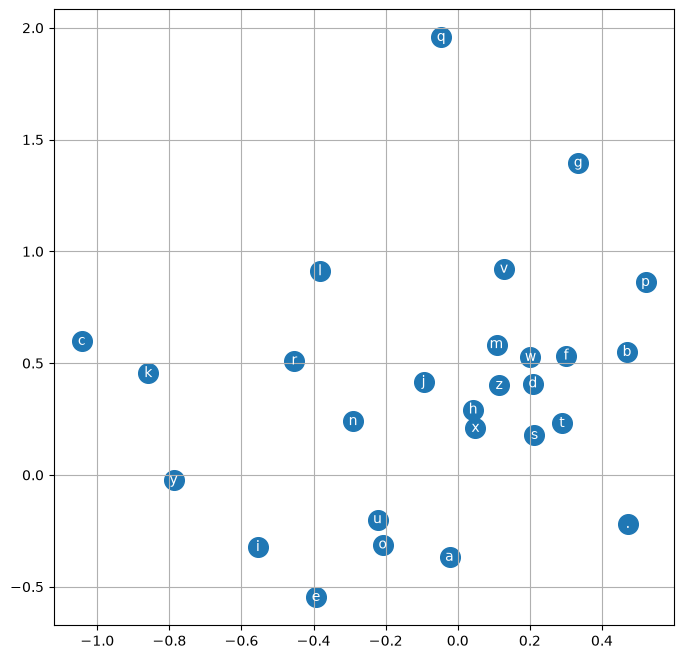

In [288]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

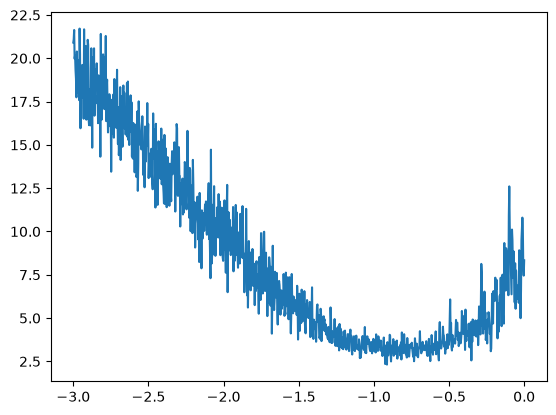

In [245]:
plt.plot(lri, lossi)

In [174]:
torch.randint(0, X.shape[0], (32,))

tensor([113670, 190126, 102164,   7242, 181571, 197931,  45808, 198136, 177369,
        202688,  76407,  13431, 202113, 119355,  86661,   3359, 168216,  10497,
         84245, 219220,  53082, 161680,   4500, 178688, 159391,  11245,   1983,
        116917,  74828,  18274,  67127, 219472])

In [167]:
logits.max(1)

torch.return_types.max(
values=tensor([ 7.8200,  9.4989,  9.8812,  ..., 11.4808, 11.2205, 11.3005],
       grad_fn=<MaxBackward0>),
indices=tensor([ 0, 14, 18,  ..., 14, 20,  9]))

In [261]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [305]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [339]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
ambrie.
khyson.
xith.
cassanden.
jazonen.
deliah.
jareei.
nellara.
chaiir.
kaleigh.
ham.
joce.
quinton.
lilea.
jadiq.
waterridiarisi.
jace.
piructus.
deci.
